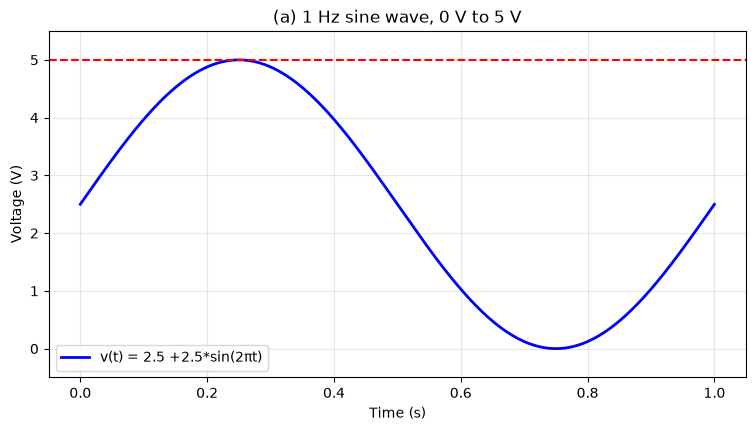

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

t = np.linspace(0, 1, 2000)
v = 2.5 + 2.5 * np.sin(2 * np.pi * t)

plt.figure(figsize=(9, 4.5))
plt.plot(t, v, 'b-', lw=2, label='v(t) = 2.5 +2.5*sin(2πt)')
plt.axhline(5, ls='--', c='r')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title( '(a) 1 Hz sine wave, 0 V to 5 V')
plt.ylim(-0.5, 5.5)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

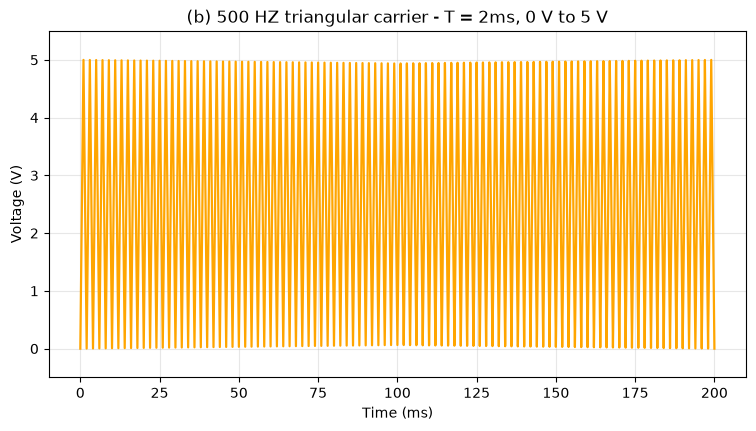

In [2]:
t_b = np.linspace(0, 0.20, 8000)
frac_b = (500 * t_b) % 1
tri_b = 5 * (1 - 2 * np.abs(frac_b - 0.5))

plt.figure(figsize=(9, 4.5))
plt.plot(t_b * 1000, tri_b, color='orange', lw=1.6)
plt.xlabel( 'Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('(b) 500 HZ triangular carrier - T = 2ms, 0 V to 5 V')
plt.ylim(-0.5, 5.5)
plt.grid(alpha=0.3)
plt.show()

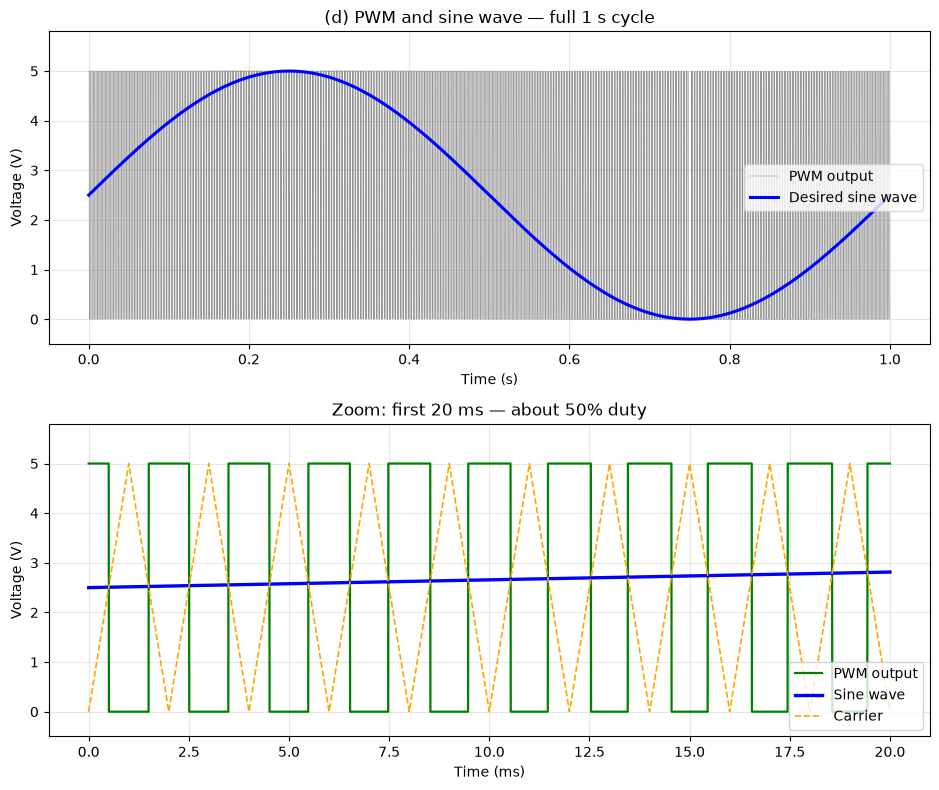

In [3]:
fs = 200_000
t = np.arange(0, 1, 1/fs)

sine = 2.5 + 2.5 * np.sin(2 * np.pi * t)
frac = (500 * t) % 1
tri  = 5 * (1 - 2 * np.abs(frac - 0.5))
pwm  = np.where(sine > tri, 5, 0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 8))

ax1.plot(t, pwm, color='gray', lw=0.3, label='PWM output')
ax1.plot(t, sine, 'b-', lw=2.2, label='Desired sine wave')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Voltage (V)')
ax1.set_title('(d) PWM and sine wave — full 1 s cycle')
ax1.set_ylim(-0.5, 5.8); ax1.grid(alpha=0.3); ax1.legend()

m = t <= 0.020
ax2.plot(t[m]*1000, pwm[m], 'g-', lw=1.6, label='PWM output')
ax2.plot(t[m]*1000, sine[m], 'b-', lw=2.4, label='Sine wave')
ax2.plot(t[m]*1000, tri[m], '--', color='orange', lw=1.2, label='Carrier')
ax2.set_xlabel('Time (ms)'); ax2.set_ylabel('Voltage (V)')
ax2.set_title('Zoom: first 20 ms — about 50% duty')
ax2.set_ylim(-0.5, 5.8); ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.show()

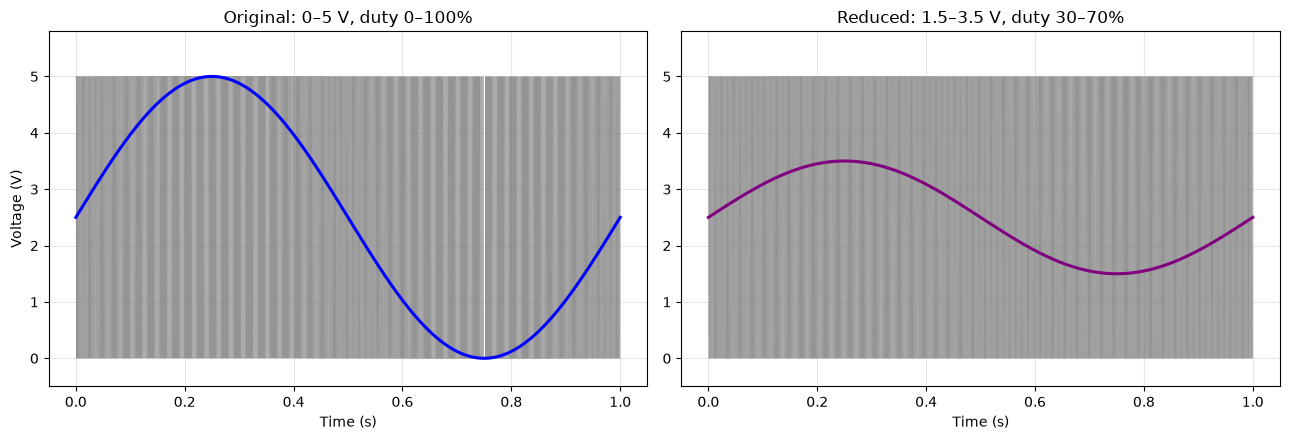

Original duty range: 0.0% to 100.0%
Reduced  duty range: 30.0% to 70.0%


In [4]:
sine2 = 2.5 + 1.0 * np.sin(2 * np.pi * t)
pwm2  = np.where(sine2 > tri, 5, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(t, pwm, color='gray', lw=0.3)
ax1.plot(t, sine, 'b-', lw=2.2)
ax1.set_title('Original: 0–5 V, duty 0–100%')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Voltage (V)')
ax1.set_ylim(-0.5, 5.8); ax1.grid(alpha=0.3)

ax2.plot(t, pwm2, color='gray', lw=0.3)
ax2.plot(t, sine2, color='purple', lw=2.2)
ax2.set_title('Reduced: 1.5–3.5 V, duty 30–70%')
ax2.set_xlabel('Time (s)')
ax2.set_ylim(-0.5, 5.8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Original duty range: %.1f%% to %.1f%%' % (sine.min()/5*100, sine.max()/5*100))
print('Reduced  duty range: %.1f%% to %.1f%%' % (sine2.min()/5*100, sine2.max()/5*100))

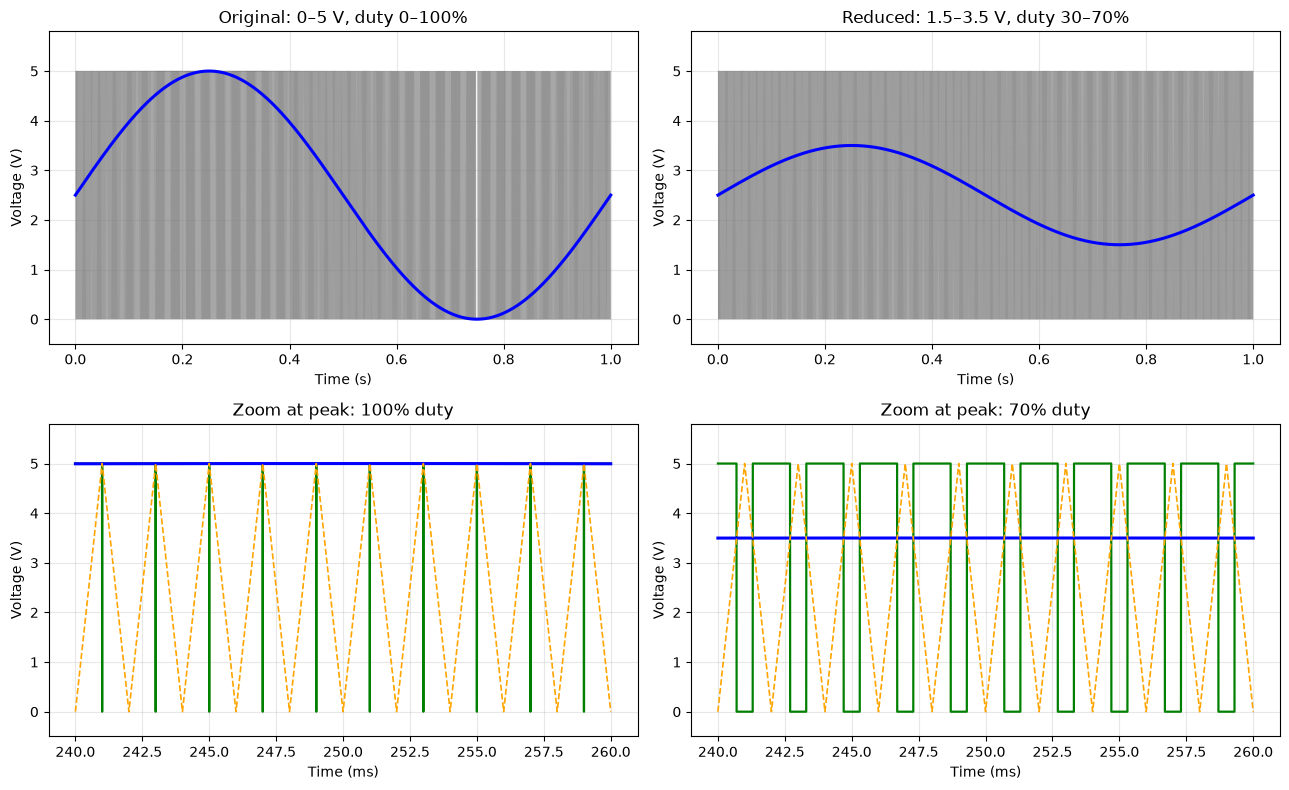

Original duty: 0–100%
Reduced  duty: 30–70%


In [5]:
sine2 = 2.5 + 1.0 * np.sin(2 * np.pi * t)
pwm2  = np.where(sine2 > tri, 5, 0)

m = (t >= 0.240) & (t <= 0.260)          # zoom window at the sine peak
cases = [(sine, pwm, 'Original: 0–5 V, duty 0–100%'),
         (sine2, pwm2, 'Reduced: 1.5–3.5 V, duty 30–70%')]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for i, (s, p, title) in enumerate(cases):
    axes[0,i].plot(t, p, color='gray', lw=0.3)
    axes[0,i].plot(t, s, 'b-', lw=2.2)
    axes[0,i].set_title(title)
    axes[0,i].set_xlabel('Time (s)')

    axes[1,i].plot(t[m]*1000, p[m], 'g-', lw=1.6)
    axes[1,i].plot(t[m]*1000, s[m], 'b-', lw=2.2)
    axes[1,i].plot(t[m]*1000, tri[m], '--', color='orange', lw=1.2)
    axes[1,i].set_title('Zoom at peak: %.0f%% duty' % (s.max()/5*100))
    axes[1,i].set_xlabel('Time (ms)')

    for ax in (axes[0,i], axes[1,i]):
        ax.set_ylim(-0.5, 5.8)
        ax.grid(alpha=0.3)
        ax.set_ylabel('Voltage (V)')

plt.tight_layout()
plt.show()

print('Original duty: %.0f–%.0f%%' % (sine.min()/5*100, sine.max()/5*100))
print('Reduced  duty: %.0f–%.0f%%' % (sine2.min()/5*100, sine2.max()/5*100))